**_Copyright Notice_**

This notebook is available for educational purposes. You may not use or distribute this notebook for commercial purposes. You may make copies of this notebook and use or distribute it for educational purposes as long as you cite the author as the source of the notebook.

Jaeyoung Chun | School of Applied Artificial Intelligence | Handong Global University

# Train

In [1]:
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import xgboost
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Load

In [2]:
df = pd.read_parquet("./intermediate/final.parquet")

In [3]:
df

,date,home_team,away_team,goals_scored_home,goals_avg_home,goals_avg_lastn_home,goals_suf_avg_home,goals_suf_avg_lastn_home,rank_avg_home,rank_avg_lastn_home,...,goals_avg_lastn_diff,goals_suf_avg_diff,goals_suf_avg_lastn_diff,rank_avg_diff,rank_avg_lastn_diff,points_avg_diff,points_avg_lastn_diff,rank_home,rank_away,rank_diff
0,2018-08-26,Barbados,Cuba,0,2.000000,2.0,2.000000,2.0,54.000000,54.0,...,2.0,1.000000,1.0,-92.000000,-92.0,65.000000,65.000,160,181,-21
1,2018-08-29,Barbados,Cuba,0,1.000000,1.0,1.000000,1.0,117.500000,117.5,...,1.0,0.500000,0.5,-35.500000,-35.5,65.000000,65.000,160,181,-21
2,2018-09-06,Mongolia,Guam,1,4.000000,4.0,1.000000,1.0,185.000000,185.0,...,4.0,-1.000000,-1.0,0.000000,0.0,8.000000,8.000,186,190,-4
3,2018-09-06,Nepal,Bhutan,4,1.000000,1.0,2.000000,2.0,201.000000,201.0,...,1.0,0.000000,0.0,7.000000,7.0,72.000000,72.000,161,183,-22
4,2018-09-06,Bangladesh,Pakistan,1,1.000000,1.0,0.500000,0.5,191.500000,191.5,...,-1.0,-0.500000,-0.5,30.500000,30.5,20.000000,20.000,194,201,-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3275,2022-09-27,Norway,Serbia,0,1.761905,1.4,0.880952,1.0,63.547619,38.6,...,-0.8,-0.230159,0.0,9.014286,-3.4,-54.433571,-79.416,36,25,11
3276,2022-09-27,Sweden,Slovenia,1,1.411765,1.2,1.137255,2.0,51.254902,39.4,...,0.2,0.137255,0.2,-25.102241,10.2,199.336008,203.424,20,65,-45
3277,2022-09-27,Kosovo,Cyprus,5,1.434783,1.2,1.304348,1.4,77.456522,65.4,...,0.6,-0.463094,0.0,7.037917,1.6,-85.712599,-9.076,106,108,-2
3278,2022-09-27,Greece,Northern Ireland,3,1.090909,1.4,0.909091,0.2,73.931818,96.2,...,0.2,-0.369979,-1.2,16.024841,0.6,-34.891411,6.774,49,58,-9


In [4]:
df.loc[1348]

date                        2020-10-11 00:00:00
home_team                                Serbia
away_team                               Hungary
goals_scored_home                             0
goals_avg_home                         1.736842
goals_avg_lastn_home                        1.6
goals_suf_avg_home                     1.368421
goals_suf_avg_lastn_home                    1.6
rank_avg_home                         56.263158
rank_avg_lastn_home                        45.8
points_avg_home                     1477.157895
points_avg_lastn_home                    1488.8
goals_scored_away                             1
goals_avg_away                         1.315789
goals_avg_lastn_away                        1.4
goals_suf_avg_away                     1.315789
goals_suf_avg_lastn_away                    1.6
rank_avg_away                         48.263158
rank_avg_lastn_away                        31.2
points_avg_away                     1418.421053
points_avg_lastn_away                   

In [5]:
df.columns

Index(['date', 'home_team', 'away_team', 'goals_scored_home', 'goals_avg_home',
       'goals_avg_lastn_home', 'goals_suf_avg_home',
       'goals_suf_avg_lastn_home', 'rank_avg_home', 'rank_avg_lastn_home',
       'points_avg_home', 'points_avg_lastn_home', 'goals_scored_away',
       'goals_avg_away', 'goals_avg_lastn_away', 'goals_suf_avg_away',
       'goals_suf_avg_lastn_away', 'rank_avg_away', 'rank_avg_lastn_away',
       'points_avg_away', 'points_avg_lastn_away', 'goals_avg_diff',
       'goals_avg_lastn_diff', 'goals_suf_avg_diff',
       'goals_suf_avg_lastn_diff', 'rank_avg_diff', 'rank_avg_lastn_diff',
       'points_avg_diff', 'points_avg_lastn_diff', 'rank_home', 'rank_away',
       'rank_diff'],
      dtype='object')

## Input Features

In [6]:
col_features = [
    'rank_diff',    
    'goals_avg_diff',
    'goals_avg_lastn_diff',
    'goals_suf_avg_diff',
    'goals_suf_avg_lastn_diff',
    'rank_avg_diff',
    'rank_avg_lastn_diff',
    'points_avg_diff',
    'points_avg_lastn_diff'
]

In [7]:
X = df[col_features]

In [8]:
X

,rank_diff,goals_avg_diff,goals_avg_lastn_diff,goals_suf_avg_diff,goals_suf_avg_lastn_diff,rank_avg_diff,rank_avg_lastn_diff,points_avg_diff,points_avg_lastn_diff
0,-21,2.000000,2.0,1.000000,1.0,-92.000000,-92.0,65.000000,65.000
1,-21,1.000000,1.0,0.500000,0.5,-35.500000,-35.5,65.000000,65.000
2,-4,4.000000,4.0,-1.000000,-1.0,0.000000,0.0,8.000000,8.000
3,-22,1.000000,1.0,0.000000,0.0,7.000000,7.0,72.000000,72.000
4,-7,-1.000000,-1.0,-0.500000,-0.5,30.500000,30.5,20.000000,20.000
...,...,...,...,...,...,...,...,...,...
3275,11,-0.038095,-0.8,-0.230159,0.0,9.014286,-3.4,-54.433571,-79.416
3276,-45,0.030812,0.2,0.137255,0.2,-25.102241,10.2,199.336008,203.424
3277,-2,0.667341,0.6,-0.463094,0.0,7.037917,1.6,-85.712599,-9.076
3278,-9,0.067653,0.2,-0.369979,-1.2,16.024841,0.6,-34.891411,6.774


## Ground Truth

In [9]:
y_home = df['goals_scored_home']

In [10]:
y_home

0       0
1       0
2       1
3       4
4       1
       ..
3275    0
3276    1
3277    5
3278    3
3279    1
Name: goals_scored_home, Length: 3280, dtype: int64

In [11]:
y_away = df['goals_scored_away']

In [12]:
y_away

0       0
1       2
2       1
3       0
4       0
       ..
3275    2
3276    1
3277    1
3278    1
3279    0
Name: goals_scored_away, Length: 3280, dtype: int64

## Split

In [13]:
# 80/20 split — keep temporal order to avoid data leakage
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

y_home_train, y_home_test = y_home.iloc[:split_idx], y_home.iloc[split_idx:]
y_away_train, y_away_test = y_away.iloc[:split_idx], y_away.iloc[split_idx:]

In [14]:
# number of matches for training
len(X_train)

2624

In [15]:
# number of matches for testing
len(X_test)

656

## Train

In [16]:
# hyperparameter search for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'min_child_weight': [1, 5],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10]
}

In [17]:
def fit(X_train, y_train):
    
    regressor = xgboost.XGBRegressor(random_state=316)
    
    grid_search = GridSearchCV(
        regressor, param_grid, cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    return grid_search.best_estimator_, grid_search.best_params_

### Train for Home Team

Predict the number of goals scored by the home team based on the provided input features.

- `X_train`: input feuatures
- `y_home_train`: ground truth (actual goals scored by the home team)

In [18]:
%%time

model_home, params_home = fit(X_train, y_home_train)

CPU times: user 3.1 s, sys: 647 ms, total: 3.75 s
Wall time: 15.1 s


In [19]:
params_home

{'colsample_bytree': 0.8,
 'gamma': 1,
 'learning_rate': 0.01,
 'max_depth': 5,
 'min_child_weight': 5,
 'n_estimators': 200,
 'reg_alpha': 0,
 'reg_lambda': 1,
 'subsample': 0.8}

### Train for Away Team

Predict the number of goals scored by the away team based on the provided input features.

- `X_train`: input feuatures
- `y_away_train`: ground truth (actual goals scored by the away team)

In [20]:
%%time

model_away, params_away = fit(X_train, y_away_train)

CPU times: user 2.71 s, sys: 285 ms, total: 2.99 s
Wall time: 12.3 s


In [21]:
params_away

{'colsample_bytree': 0.8,
 'gamma': 1,
 'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 1,
 'n_estimators': 100,
 'reg_alpha': 0.1,
 'reg_lambda': 10,
 'subsample': 1.0}

## Evaluation

### Predicting Home Goals

In [22]:
pred_home = model_home.predict(X_test).clip(min=0)

In [23]:
pred_home

array([2.4960017 , 0.67330235, 2.304514  , 2.0903833 , 0.8460752 ,
       0.6551838 , 1.0266681 , 0.7394783 , 1.9379447 , 2.3308427 ,
       0.7142633 , 3.527188  , 1.8240983 , 1.2415174 , 0.6196256 ,
       1.7808088 , 1.8745102 , 1.4061794 , 1.6778482 , 1.4310977 ,
       2.2926638 , 1.8132397 , 2.734546  , 1.7651329 , 1.2814381 ,
       2.5229118 , 2.360994  , 0.8839166 , 2.3839598 , 1.030759  ,
       1.3792646 , 0.69163567, 1.9350075 , 1.2937913 , 1.9396605 ,
       1.4021107 , 0.80981976, 0.9653879 , 1.0357795 , 1.3571273 ,
       1.844464  , 1.7198815 , 1.6633531 , 1.0172013 , 1.3585055 ,
       1.6130986 , 0.97988063, 2.1394136 , 2.3451412 , 1.0484184 ,
       1.9240528 , 1.2077237 , 1.7243723 , 1.5272577 , 1.4399765 ,
       1.1831094 , 1.3717428 , 1.9323945 , 1.8919605 , 0.98519474,
       1.8967271 , 0.7453469 , 1.6551418 , 0.8705616 , 1.0993041 ,
       1.5348322 , 1.516469  , 1.4662573 , 2.47344   , 1.014408  ,
       2.4599693 , 1.2782218 , 0.8867405 , 1.7758919 , 1.70479

In [24]:
mae_home = mean_absolute_error(y_home_test, pred_home)
rmse_home = np.sqrt(mean_squared_error(y_home_test, pred_home))

print(f"MAE : {mae_home:.3f}")
print(f"RMSE: {rmse_home:.3f}")

MAE : 0.974
RMSE: 1.258


### Predicting Away Goals

In [25]:
pred_away = model_away.predict(X_test).clip(min=0)

In [26]:
pred_away

array([0.4972584 , 2.0675893 , 0.5201076 , 0.4773708 , 1.3037713 ,
       1.9933702 , 1.1026253 , 2.1062942 , 0.6086096 , 0.3263635 ,
       1.6127645 , 0.27041277, 0.72571653, 1.1570197 , 3.0137558 ,
       0.4175923 , 0.54924077, 0.9987967 , 0.62061244, 1.0796119 ,
       0.62184066, 0.7111596 , 0.46077847, 0.61616915, 1.0749302 ,
       0.33088994, 0.56011206, 1.6396241 , 0.3830014 , 1.5986404 ,
       0.8943036 , 2.210664  , 0.38773945, 0.8122305 , 0.55555886,
       0.814173  , 1.5458522 , 1.0661484 , 1.4811736 , 0.82634705,
       0.4991437 , 0.8540254 , 0.9458164 , 1.0741338 , 1.1149074 ,
       0.71681505, 1.1929477 , 0.68584126, 0.33088994, 1.071916  ,
       0.6498647 , 1.201458  , 0.5857476 , 1.0583259 , 0.9905173 ,
       1.0627213 , 1.106275  , 0.68797123, 0.43076575, 1.159456  ,
       0.38199896, 1.9370804 , 0.66578233, 1.5315741 , 1.3719504 ,
       0.7204731 , 0.7894351 , 0.86411136, 0.33378285, 1.1452774 ,
       0.3353532 , 1.1567235 , 1.4346277 , 0.66513604, 1.08463

In [27]:
mae_away = mean_absolute_error(y_away_test, pred_away)
rmse_away = np.sqrt(mean_squared_error(y_away_test, pred_away))

print(f"MAE : {mae_away:.3f}")
print(f"RMSE: {rmse_away:.3f}")

MAE : 0.790
RMSE: 1.078


## Visualization

### Residuals

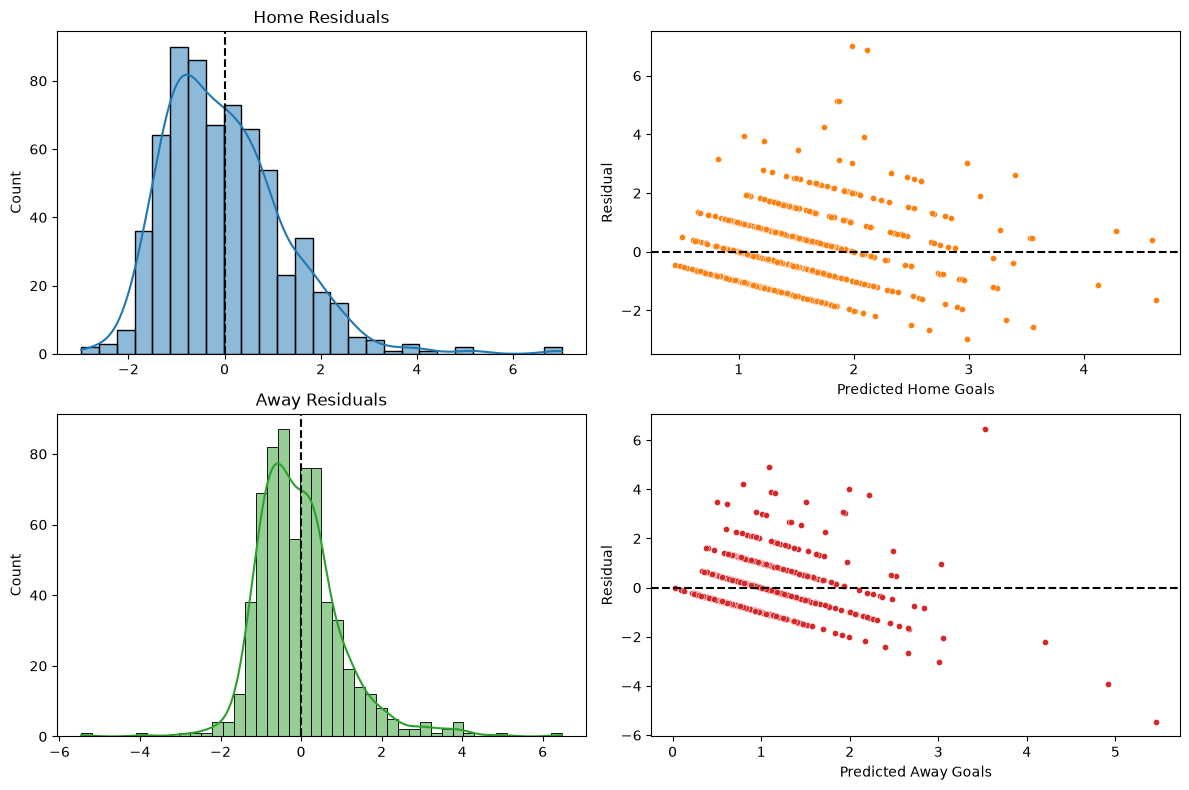

In [28]:
# obs - pred
res_home = y_home_test.values - pred_home
res_away = y_away_test.values - pred_away

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(res_home, kde=True, ax=axes[0,0], color='C0')
axes[0,0].axvline(0, color='k', ls='--')
axes[0,0].set_title('Home Residuals')

sns.scatterplot(x=pred_home, y=res_home, ax=axes[0,1], s=20, color='C1')
axes[0,1].axhline(0, color='k', ls='--')
axes[0,1].set_xlabel('Predicted Home Goals')
axes[0,1].set_ylabel('Residual')

sns.histplot(res_away, kde=True, ax=axes[1,0], color='C2')
axes[1,0].axvline(0, color='k', ls='--')
axes[1,0].set_title('Away Residuals')

sns.scatterplot(x=pred_away, y=res_away, ax=axes[1,1], s=20, color='C3')
axes[1,1].axhline(0, color='k', ls='--')
axes[1,1].set_xlabel('Predicted Away Goals')
axes[1,1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

### Actual vs. Predicted Goals

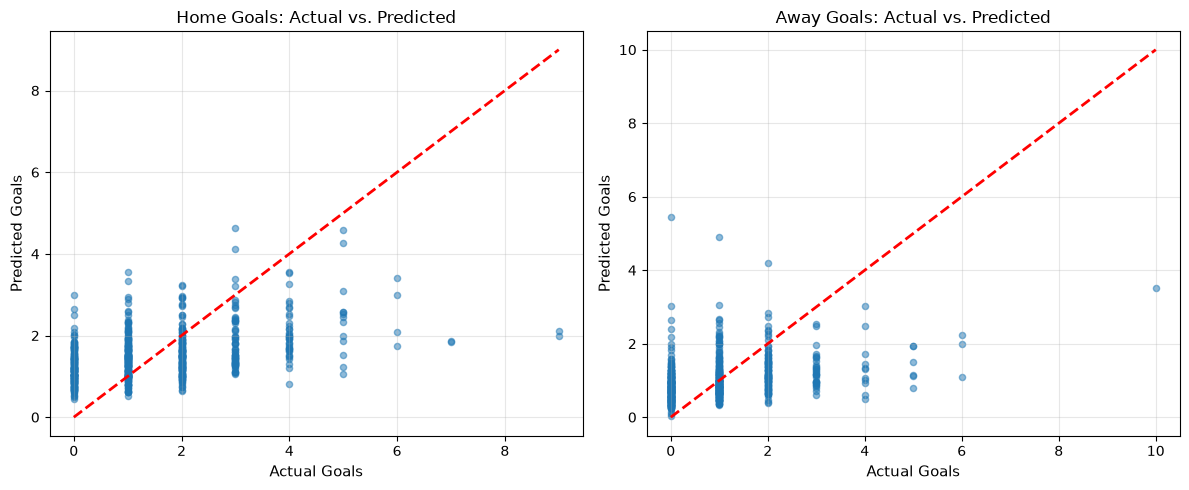

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# home goals
axes[0].scatter(y_home_test.values, pred_home, alpha=0.5, s=20)
axes[0].plot(
    [y_home_test.min(), y_home_test.max()], 
    [y_home_test.min(), y_home_test.max()],
    'r--', lw=2
)
axes[0].set_xlabel('Actual Goals', fontsize=11)
axes[0].set_ylabel('Predicted Goals', fontsize=11)
axes[0].set_title('Home Goals: Actual vs. Predicted', fontsize=12)
axes[0].grid(alpha=0.3)

# away goals
axes[1].scatter(y_away_test.values, pred_away, alpha=0.5, s=20)
axes[1].plot(
    [y_away_test.min(), y_away_test.max()], 
    [y_away_test.min(), y_away_test.max()],
    'r--', lw=2
)
axes[1].set_xlabel('Actual Goals', fontsize=11)
axes[1].set_ylabel('Predicted Goals', fontsize=11)
axes[1].set_title('Away Goals: Actual vs. Predicted', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Feature Importance

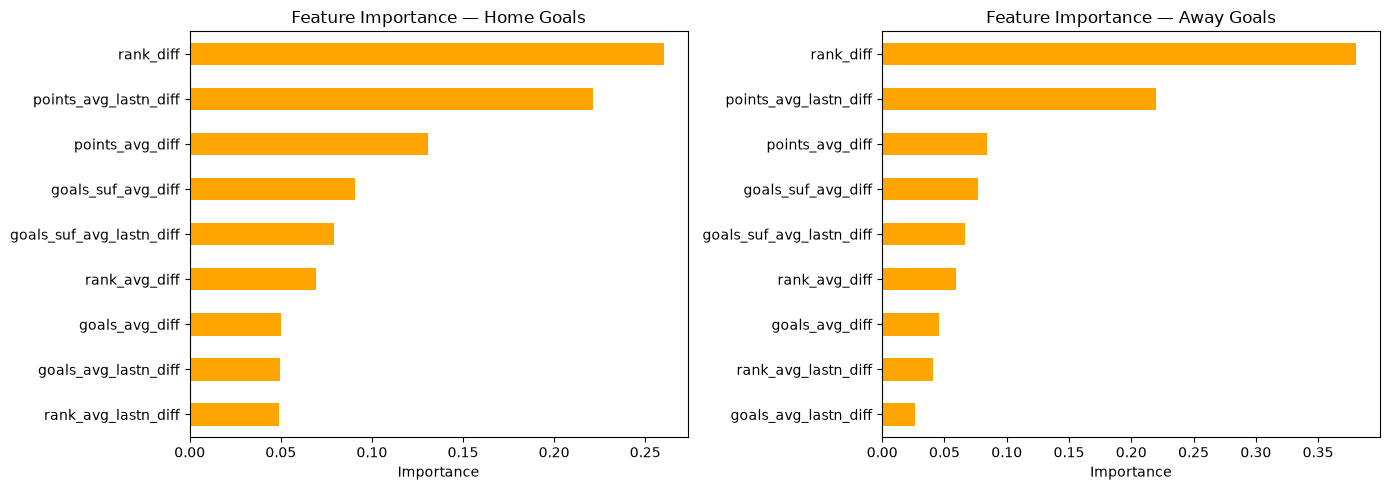

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(axes, [model_home, model_away], ['Home Goals', 'Away Goals']):

    importance = pd.Series(model.feature_importances_, index=col_features).sort_values()
    
    importance.plot(kind="barh", color='orange', ax=ax)
    
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Save

In [31]:
models = {
    "home": model_home,
    "away": model_away,
    "col_features": col_features
}

In [32]:
with open("./intermediate/models.pickle", "wb") as fout:
    pickle.dump(models, file=fout)